## 1. Environment Setup

Install Required Library

In [ ]:
!pip install nltk
!pip install pyspark
!pip install pyspark spark-nlp
!pip install keras --upgrade

#### 1.1 Create SparkContext and SparkSession

Remeber to create a session, which is an entry point to Spark

In [ ]:
# create entry points to spark
from pyspark.sql import SparkSession

ss  = SparkSession.builder \
        .appName("Spark NLP") \
        .config("spark.jars.packages", "com.johnsnowlabs.nlp:spark-nlp_2.12:5.3.3") \
        .getOrCreate()
spark = ss.sparkContext

## 2. Train the text embedding model.

In this section, we will conduct text embedding using the Brown toy dataset from the NLTK library. We will leverage SparkNLP to perform a range of pre-processing tasks. Following that, we will assign an index to each word to prepare the training data. Finally, we will set up our TensorFlow model for training.

### 2.1 Pre-process the text
First, we download the Brown dataset from NLTK and store it in a DataFrame.


In [ ]:
import sparknlp
import nltk
nltk.download('brown')
from nltk.corpus import brown  # brown is a toy document come with nltk library
from pyspark.conf import SparkConf

spark = sparknlp.start()
def detokenize(sentence):
  text = ''
  for token in sentence:
    if text and any(c.isalnum() for c in token): # remove sentences that contain only number
      text += ' '
    text += token
  return text

texts=[]


for fid in brown.fileids()[0:100]:
  text = [detokenize(s) for s in brown.sents(fid)]
  text = ' '.join(text)
  texts.append((text,))

texts = spark.createDataFrame(texts,['text'])

texts.show()

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


+--------------------+
|                text|
+--------------------+
|The Fulton County...|
|Austin, Texas -- ...|
|Several defendant...|
|Oslo The most pos...|
|East Providence s...|
|Plainfield -- Jam...|
|Resentment welled...|
|Appointment of Wi...|
|City Controller A...|
|Vincent G. Ierull...|
|Miami, Fla., Marc...|
|Austin, Texas -- ...|
|Rookie Ron Nischw...|
|Philadelphia, Jan...|
|If the Cardinals ...|
|Romantic news con...|
|After being close...|
|`` A Night in New...|
|The Baltimore and...|
|London, Feb. 9 --...|
+--------------------+
only showing top 20 rows



### 2.2 Preprocess the text

The cell below uses the Spark NLP library to build a processing pipeline for text data. The pipeline takes raw text, breaks it into sentences and tokens, converts everything to lowercase, and prepares it for further use.

``DocumentAssembler``
The entry point for any Spark NLP pipeline. It prepares data in a format that Spark NLP can process. It takes a raw text column (in this case, 'text') and converts it into a DOCUMENT type annotation that subsequent annotators in the pipeline can use.

``SentenceDetector``: Breaks down the text into individual sentences. Breaks a document into an array of sentence annotations.

``Tokenizer``: breaks each sentence into individual words, or "tokens".

``Normalizer``: cleans and normalizes the tokens. We apply normalizer to convert all tokens to lowercase.

``Finisher``: converts the Spark NLP annotation results into a standard, readable format


In [ ]:
# Preprocess the text
from pyspark.ml import Pipeline
from sparknlp import DocumentAssembler, Finisher
from sparknlp.annotator import *

spark = sparknlp.start()

assembler = DocumentAssembler()\
        .setInputCol('text')\
        .setOutputCol('document')

sentence = SentenceDetector()\
        .setInputCols(["document"])\
        .setOutputCol("sentences")\
        .setExplodeSentences(True)

tokenizer = Tokenizer()\
        .setInputCols(['sentences'])\
        .setOutputCol('token')

# lowcase the text
normalizer = Normalizer()\
        .setInputCols(['token'])\
        .setOutputCol('normalized')\
        .setLowercase(True)

finisher = Finisher()\
        .setInputCols(['normalized'])\
        .setOutputCols(['normalized'])\
        .setOutputAsArray(True)

pipeline = Pipeline().setStages([assembler, sentence, tokenizer, normalizer, finisher]).fit(texts)

sentences = pipeline.transform(texts)
sentences = sentences.select('normalized').collect()
sentences = [r['normalized'] for r in sentences]
print(len(sentences)) # number of sentences

10751


### 2.3 Assign an ID to each word in the document

Neural networks operate on numerical data, not raw text. Therefore, we must create a vocabulary and assign a unique integer index to each unique word. The special <PAD> (padding) token, indexed as 0, is used to ensure all input sequences have a uniform length for efficient batch processing. The <UNK> (unknown) token, indexed as 1, is used to represent words not found in our pre-defined vocabulary, which is essential for handling new or rare words during inference.

In [ ]:
from collections import Counter
import numpy as np
import pandas as pd

UNK ='???'
PAD ='###'
w2i ={PAD:0,UNK:1}
df = Counter()

for s in sentences:
  df.update(s)
df = pd.Series(df)
df

for word in df.index:
  w2i[word] = len(w2i)

i2w = {ix: w for w, ix in w2i.items()}
vocab_size = len(i2w)

print(vocab_size)

display = 0
for k, v in i2w.items():
  if display < 10:
    print(k, v)
    display+=1
  else:
    break


20296
0 ###
1 ???
2 the
3 fulton
4 county
5 grand
6 jury
7 said
8 friday
9 an


### 2.4 Assign an ID to each word in the document

The ``texts_to_sequences`` function uses nested list comprehension to iterate through a list of sentences and, for each word, retrieves its corresponding integer from a word-to-index dictionary (w2i).
  - To handle words not present in the vocabulary, it gracefully falls back to a special index for an unknown token (UNK) using the dictionary's get method.

The ``sequences_to_texts`` function translates a numerical sequence back into a readable sentence by mapping each index back to its original word using an index-to-word dictionary (i2w).

In [ ]:
# represent each sentence in the doc as a list of word ID
def texts_to_sequences(texts):
  return[[w2i.get(w,w2i[UNK]) for w in s] for s in texts]

def sequences_to_texts(seqs):
  return [' '.join([i2w.get(ix,UNK) for ix in s]) for s in seqs]

seqs = texts_to_sequences(sentences)

for i, s in enumerate(seqs[0:10]):
   print(sentences[i])
   print(s)
   print()

['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', 'atlantas', 'recent', 'primary', 'election', 'produced', 'no', 'evidence', 'that', 'any', 'irregularities', 'took', 'place']
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

['the', 'jury', 'further', 'said', 'in', 'termend', 'presentments', 'that', 'the', 'city', 'executive', 'committee', 'which', 'had', 'overall', 'charge', 'of', 'the', 'election', 'deserves', 'the', 'praise', 'and', 'thanks', 'of', 'the', 'city', 'of', 'atlanta', 'for', 'the', 'manner', 'in', 'which', 'the', 'election', 'was', 'conducted']
[2, 6, 24, 7, 25, 26, 27, 19, 2, 28, 29, 30, 31, 32, 33, 34, 11, 2, 15, 35, 2, 36, 37, 38, 11, 2, 28, 11, 39, 40, 2, 41, 25, 31, 2, 15, 42, 43]

['the', 'septemberoctober', 'term', 'jury', 'had', 'been', 'charged', 'by', 'fulton', 'superior', 'court', 'judge', 'durwood', 'pye', 'to', 'investigate', 'reports', 'of', 'possible', 'irregularities', 'in', 'the', 

### 2.5 Setup the training data

**Window Definition**: A window size w is set to 4, defining a window of 9 words in total (4 words before, the center word, and 4 words after).

**Window Generation**: The code iterates through every sentence ``seq`` and then through every word ``i`` within that sentence. For each word, it constructs a list representing its context window.

**Boundary Handling**: To maintain a consistent window size, it handles the edges of sentences by adding a special ``PAD`` token for any positions outside the sentence boundaries. This ensures that the model always receives a fixed-size input.

**Output Format**: All the generated windows are stored in a list, which is finally converted into a NumPy array. This array holds the numerical representations of each word and its context, ready for training a neural network.

In [ ]:
w=4
windows =[]

Y=[]
for k, seq in enumerate(seqs):
  for i in range(len(seq)):
    #if seq[i]==w2i[UNK] or len(seq) < 2*w:
      #continue
    window = []
    for j in range(-w, w+1):
      if i+j < 0:
        window.append(w2i[PAD])
      elif i+j >= len(seq):
        window.append(w2i[PAD])
      else:
        window.append(seq[i+j])
    windows.append(window)
windows = np.array(windows)

In [ ]:
def windows_to_batch(batch_windows):
  w = batch_windows.shape[1] // 2
  X = []
  Y = []
  for window in batch_windows:
    X.append(np.concatenate((window[:w],window[w+1:])))
    Y.append(window[w])
  X = np.array(X)
  Y = ku.to_categorical(Y,vocab_size)
  return X,Y

In [ ]:
def generate_batch(windows, batch_size=100):
  while True:
    indices = np.arange(windows.shape[0])
    indices = np.random.choice(indices,batch_size)
    batch_windows = windows[indices, :]
    yield windows_to_batch(batch_windows)

## 2.6 Setup the neural network model with Three layers as follow.

Layer 1: ``Embedding(vocab_size, dim, input_length=w*2)``
- This is the first layer, designed to handle categorical data (like words). It converts integer-encoded words into dense, fixed-size vectors called word embeddings.
  - vocab_size: The size of your vocabulary (the total number of unique words plus special tokens like UNK and PAD). It tells the embedding layer how many unique items it needs to represent.
  - dim: The dimensionality of the embedding vectors. In this case, each word will be represented by a 25-dimensional vector.
  - input_length=w*2: This defines the length of the input sequences. For instance, in a word prediction task, w*2 might represent the context window around a target word.

Layer 2: ``Lambda(lambda x: K.mean(x, axis=1),(dim,)))``

- This layer is used to wrap an arbitrary expression as a layer. It is often used for simple, stateless operations.

  - It computes the mean of the input tensor x along axis=1.
  - K.mean(x, axis=1): The Embedding layer's output has a shape of (batch_size, input_length, dim). The mean operation collapses the input_length dimension by taking the average of all the word vectors in a sequence. This effectively creates a single context vector that represents the entire input sequence.
  - (dim,): This specifies the output shape of the Lambda layer. The input sequence of length w*2 is averaged, resulting in a single vector of size dim.

Layer 3: ``Dense(vocab_size, activation='softmax')``
- Dense: This is a standard, fully connected neural network layer.
  - vocab_size: The number of units in the Dense layer. This is the output layer, and the number of units corresponds to the number of possible words in your vocabulary.
  - activation='softmax': The softmax activation function is used to produce a probability distribution over the vocab_size output units. The output of this layer can be interpreted as the probability of each word in the vocabulary being the predicted next word

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
import tensorflow.keras.backend as K
import tensorflow.keras.utils as ku

dim = 25
model = Sequential()
model.add(Embedding(vocab_size, dim,input_length=w*2))
model.add(Lambda(lambda x: K.mean(x, axis=1),(dim,)))
model.add(Dense(vocab_size, activation='softmax'))

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


Specify the loss function as categorical_crossentropy and the optimizer as Adaptive Moment Estimation

- Categorical cross-entropy is a standard choice for multi-class classification problems

- Adaptive Moment Estimation is one of the most popular and robust optimizers in deep learning. It uses the loss value calculated in each training step to determine how to adjust the model's weights to reduce the loss in the next step.

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer='adam')

## 2.7 Train the model.


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

batch_size = 1000
steps_per_epoch = 5  # More descriptive name
epochs = 10  # Plural for standard convention

# Use Keras' automatic epoch formatting
saveFile = '{epoch:02d}.weights.h5'  # Will create weights_01.h5, etc.

# Keep generator initialization similar
train_generator = generate_batch(windows, batch_size)

# Modern checkpoint configuration
checkpoint = ModelCheckpoint(
    filepath=saveFile,
    save_weights_only=True,
    save_freq=steps_per_epoch * 1  # Save every epoch
)

# Updated training call with generator support
model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    callbacks=[checkpoint]
)

# Show save pattern instead of specific file
print(f"Checkpoint pattern: {saveFile}")

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 421ms/step - loss: 9.9160
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 417ms/step - loss: 9.9102
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 415ms/step - loss: 9.9031
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 444ms/step - loss: 9.8933
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 602ms/step - loss: 9.8794
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 415ms/step - loss: 9.8572
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 418ms/step - loss: 9.8247
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 417ms/step - loss: 9.7784
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 426ms/step - loss: 9.7146
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 531ms/step - loss: 9.6286
Checkpoint pattern: {epoch:02d}.weights.h5


## 2.8 Create a class for Word2Vec


In [ ]:
class Word2VecData(object):
    def __init__(self, word_vectors, w2i, i2w):
        self.word_vectors = word_vectors
        self.w2i = w2i
        self.i2w = i2w

        # Normalized vectors for cosine similarity
        self.normed_wv = np.divide(word_vectors.T, np.linalg.norm(word_vectors, axis=1)).T
        self.all_sims = np.dot(self.normed_wv, self.normed_wv.T)
        self.all_sims = np.triu(self.all_sims)
        self.all_sims = self.all_sims[self.all_sims > 0]

    # This transforms a word into a vector
    def w2v(self, word):
        return self.word_vectors[self.w2i[word], :]

    # This calculates cosine similarity of the input word to all words
    def _get_sims(self, word):
        if isinstance(word, str):
            v = self.w2v(word)
        else:
            v = word
        v = np.divide(v, np.linalg.norm(v))
        return np.dot(self.normed_wv, v)

    def nearest_words(self, word, k=10):
        sims = self._get_sims(word)
        nearest = sims.argsort()[-k:][::-1]
        ret = []
        for ix in nearest:
            ret.append((self.i2w[ix], sims[ix]))
        return ret

    def compare_words(self, u, v):
        if isinstance(u, str):
            u = self.w2v(u)
        if isinstance(v, str):
            v = self.w2v(v)
        u = np.divide(u, np.linalg.norm(u))
        v = np.divide(v, np.linalg.norm(v))
        return np.dot(u, v)

In [ ]:
# Compute Word-Word Similarity
import matplotlib.pyplot as plt
%matplotlib inline

def display_Word2vec(model, weight_path, words, analogies):
    model.load_weights(weight_path)
    word_vectors = model.layers[0].get_weights()[0]
    W2V = Word2VecData(word_vectors, w2i, i2w)

    for word in words:
        for w, sim in W2V.nearest_words(word):
            print(w, sim)
        print()

    for w1, w2, w3, w4 in analogies:
        v1 = W2V.w2v(w1)
        v2 = W2V.w2v(w2)
        v3 = W2V.w2v(w3)
        v4 = W2V.w2v(w4)
        x = v1 - v2 + v3
        for w, sim in W2V.nearest_words(x):
            print(w, sim)
        print()
        print(w4, W2V.compare_words(x, v4))
        print()
        print(f'{w1}-{w2}+{w3}~{w4} quantile', (W2V.all_sims < W2V.compare_words(x, v4)).mean())
        print()

    plt.hist(W2V.all_sims)
    plt.title('Word-to-Word similarity histogram')
    plt.show()


king 1.0
city 0.7962664
effort 0.78843844
important 0.7850972
into 0.76625365
much 0.7640982
unity 0.76055205
san 0.7525543
driver 0.7395673
dance 0.73624635

man 0.90970856
texas 0.8707396
as 0.8685152
later 0.86460465
is 0.8612149
being 0.86010134
give 0.85908854
also 0.8557769
at 0.85263324
this 0.8501852

queen 0.50159264

man-king+woman~queen quantile 0.9795425286579713



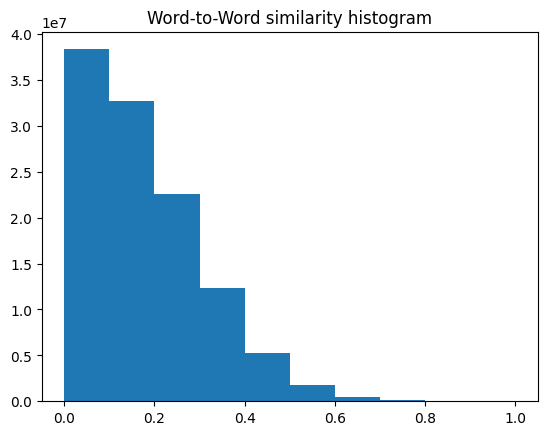

In [ ]:
 saveFile = "10.weights.h5"
 display_Word2vec(model, saveFile, ['king'], [('man', 'king', 'woman', 'queen')]) # saveFile: weights.{epoch}.h5

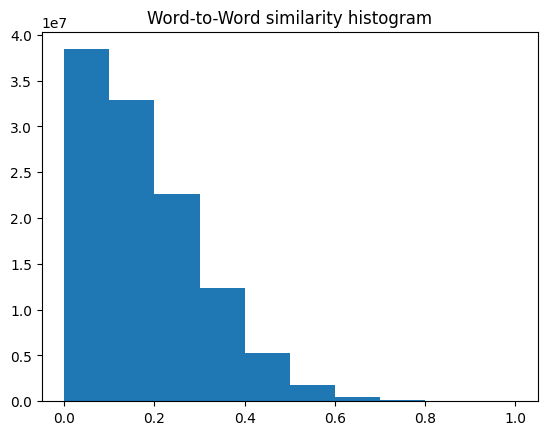

The x-axis represents the similarity scores, ranging from 0.0 to 1.0. A score closer to 1.0 indicates a higher degree of similarity between two words

The y-axis represents the frequency or count of word pairs that fall into each similarity score bin.

The shape of the histogram indicates that a large number of word pairs have very low similarity scores, shown by the tall bar on the far left. As the similarity score increases, the frequency of word pairs with that score decreases significantly, with very few pairs having high similarity scores (close to 1.0).


## 2.9 Incorporate externally trained Word2vec models

Spark NLP lets us incorporate externally trained Word2vec models. Let's see how we can use these word embeddings in Spark NLP. First, let's write the embeddings to a file in a format that Spark NLP is familiar with.

In [ ]:
model.load_weights(saveFile)
word_vectors = model.layers[0].get_weights()[0]

with open('cbow.csv','w') as out:
  for ix in range(vocab_size):
    word = i2w[ix]
    vec = list(word_vectors[ix, :])
    line =['{}']+['{:.18e}']*dim
    line =' '.join(line) +'\n'
    line = line.format(word,*vec)
    out.write(line)

Now we can create an embeddings annotator.

In [ ]:
from pyspark.ml import Pipeline

Word2vec = WordEmbeddings()\
        .setInputCols(['document','normalized'])\
        .setOutputCol('embeddings')\
        .setDimension(dim)\
        .setStoragePath('cbow.csv','TEXT')

pipeline = Pipeline().setStages([assembler, sentence, tokenizer,normalizer,Word2vec]).fit(texts)

Let's get out the embeddings generated by our model.

In [ ]:
pipeline.transform(texts)

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|                text|            document|           sentences|               token|          normalized|          embeddings|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|The Fulton County...|[{document, 0, 12...|[{document, 0, 15...|[{token, 0, 2, Th...|[{token, 0, 2, th...|[{word_embeddings...|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
only showing top 1 row



In [ ]:
pipeline.transform(texts).select('embeddings.embeddings')\
    .first()['embeddings']

[[0.610017716884613,
  -0.7779504656791687,
  -0.4627123773097992,
  0.7349762916564941,
  0.42238467931747437,
  -0.7293720245361328,
  -0.5237522125244141,
  -0.7519598603248596,
  0.4598037302494049,
  0.77195805311203,
  -0.8350094556808472,
  -0.7631781697273254,
  0.6397668719291687,
  -0.7350988984107971,
  -0.7277117371559143,
  -0.6967498064041138,
  0.7278863787651062,
  0.5793663859367371,
  0.7721375226974487,
  0.7914381623268127,
  -0.7600310444831848,
  0.566770076751709,
  -0.5093353986740112,
  -0.5809828042984009,
  -0.8209589123725891],
 [0.02729959785938263,
  -0.04555705934762955,
  -0.009470727294683456,
  -0.030367931351065636,
  0.03229412063956261,
  0.011162586510181427,
  -0.035303566604852676,
  0.006595337763428688,
  -0.011224106885492802,
  0.04052901640534401,
  0.014094671234488487,
  0.016896968707442284,
  -0.03174799680709839,
  -0.052246760576963425,
  -0.00656196428462863,
  0.02130059339106083,
  0.028099089860916138,
  -0.027906781062483788,
  0.

In [ ]:
# Now we can directly use the Word2vec for text encoding (i.e., convert the word in your doc into word vec)

from pyspark.ml.feature import Word2Vec
Word2vec = Word2Vec()\
      .setInputCol('normalized')\
      .setOutputCol('word_vectors')\
      .setVectorSize(dim)\
      .setMinCount(5)
finisher = Finisher()\
      .setInputCols(['normalized'])\
      .setOutputCols(['normalized'])\
      .setOutputAsArray(True)

pipeline = Pipeline().setStages([assembler, sentence, tokenizer,normalizer,finisher])
df = pipeline.fit(texts).transform(texts)

In [ ]:
model2 = Word2vec.fit(df)
model2.transform(df).select('word_vectors').first()['word_vectors']

DenseVector([-0.0529, -0.02, 0.0201, 0.0437, 0.0372, -0.0006, -0.0057, 0.021, -0.0027, 0.0311, -0.0292, 0.0306, 0.0482, 0.0026, -0.0495, 0.0191, -0.0309, -0.0417, 0.0534, -0.025, -0.0083, 0.0162, -0.0592, -0.0075, 0.0524])